# Universidad de Buenos Aires - FIUBA - LSE
## Aprendizaje Profundo - TP1 - Cohorte 26 - 4to bimestre 2026

#### **Alumno 1:** Lerner, Federico Ezequiel - a2619
#### **Alumno 2:** Makk, Azul de los Angeles - a2622
#### **Alumno 3:** Moguilner Reh, Nicolás Francisco - a2623

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 18 de septiembre (hora de Argentina)**.

La resolución del TP puede realizarse de forma **individual, en parejas o hasta en grupos de 3 como máximo**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que todos los integrantes deben trabajar conjuntamente en la resolución de cada pregunta.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

Se comparan los optimizadores Gradiente Descendente (GD) y Adam en la minimización del MSE de una red de una sola conexión sináptica:

$$\hat{y} = \tanh(wx+b), \qquad J(w,b)=\frac{1}{m}\sum_{i=1}^m(\tanh(wx_i+b)-y_i)^2$$

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

SEED = 42
rng = np.random.default_rng(SEED)
%matplotlib inline

### Por qué elegimos este dataset

Si usábamos una `tanh` sola como patrón no lineal, la red la iba a poder ajustar casi perfecto porque la activación de la neurona es justamente esa misma función, y el ejercicio de comparar optimizadores no tendría mucho sentido (no quedaría error para minimizar). Por eso combinamos un seno con una cúbica pasada por `tanh`: así el patrón tiene curvas que una sola neurona no puede seguir, ya que $\tanh(wx+b)$ siempre es monótona en $x$ (creciente o decreciente) y el seno no lo es. Nos queda entonces un piso de error que no se puede bajar más con esta arquitectura, que es justo lo que nos interesa como referencia para comparar qué tan rápido y qué tan bien se acerca cada optimizador a ese piso.

$$f(x) = 0.6\sin(1.5x) + 0.3\tanh(0.4x^3)$$

con $x\in[-3,3]$ (300 puntos) y ruido gaussiano chico agregado sobre $y$.

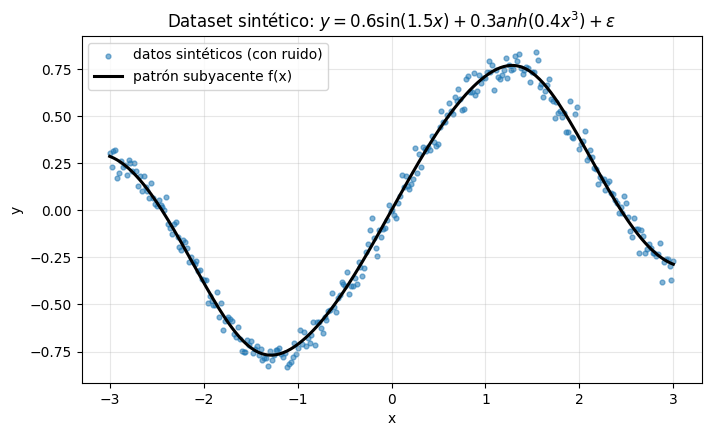

In [24]:
n = 300
x = np.linspace(-3, 3, n)
noise = rng.normal(0, 0.05, size=n)

def y_true_fn(x):
    return 0.6 * np.sin(1.5 * x) + 0.3 * np.tanh(0.4 * x**3)

y = y_true_fn(x) + noise

plt.figure(figsize=(8, 4.5))
plt.scatter(x, y, s=12, alpha=0.55, label="datos sintéticos (con ruido)")
plt.plot(x, y_true_fn(x), color="black", lw=2.2, label="patrón subyacente f(x)")
plt.xlabel("x"); plt.ylabel("y")
plt.title(r"Dataset sintético: $y = 0.6\sin(1.5x) + 0.3	anh(0.4x^3) + \epsilon$")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### 1a) Implementación del Gradiente Descendente (1 punto)

In [25]:
def forward(w, b, x):
    z = w * x + b
    return np.tanh(z), z

def cost_fn(w, b, x, y):
    yhat, _ = forward(w, b, x)
    return np.mean((yhat - y) ** 2)

def grad_fn(w, b, x, y):
    # dJ/dz = (2/m)(yhat-y)(1-yhat^2), por regla de la cadena con d(tanh)/dz = 1 - tanh(z)^2
    m = x.shape[0]
    yhat, _ = forward(w, b, x)
    dz = (2.0 / m) * (yhat - y) * (1 - yhat ** 2)
    dw = np.sum(dz * x)
    db = np.sum(dz)
    return dw, db

# Misma inicialización aleatoria para GD y para Adam (1b), tal como pide la consigna
np.random.seed(SEED)
w0, b0 = np.random.randn(), np.random.randn()
print(f"w0={w0:.4f}, b0={b0:.4f}")

EPOCHS = 100
LRS = [0.1, 0.01, 0.001]
COLORS = {0.1: "tab:red", 0.01: "tab:blue", 0.001: "tab:green"}

w0=0.4967, b0=-0.1383


GD  lr=0.1    costo final=0.18834  w=0.1400  b=-0.0022
GD  lr=0.01   costo final=0.19461  w=0.1880  b=-0.0480
GD  lr=0.001  costo final=0.29034  w=0.4662  b=-0.1290


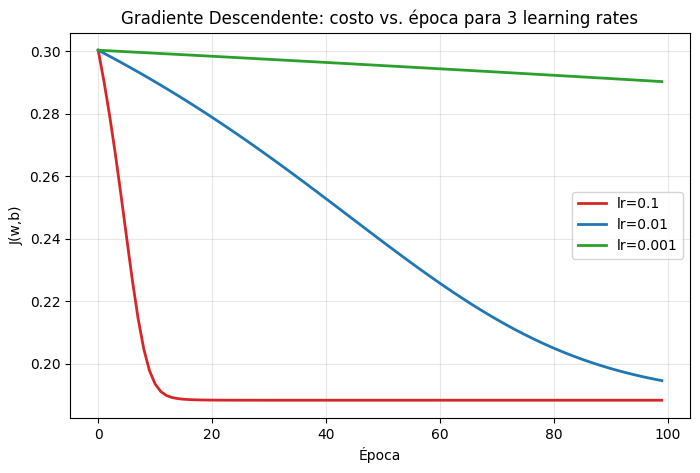

In [26]:
def gradient_descent(lr, epochs=EPOCHS):
    w, b = w0, b0
    costs, ws, bs = [], [], []
    for _ in range(epochs):
        costs.append(cost_fn(w, b, x, y))
        ws.append(w); bs.append(b)
        dw, db = grad_fn(w, b, x, y)
        w -= lr * dw
        b -= lr * db
    return np.array(costs), np.array(ws), np.array(bs), w, b

gd_hist = {}
for lr in LRS:
    costs, ws, bs, wf, bf = gradient_descent(lr)
    gd_hist[lr] = dict(costs=costs, ws=ws, bs=bs, wf=wf, bf=bf)
    print(f"GD  lr={lr:<6} costo final={costs[-1]:.5f}  w={wf:.4f}  b={bf:.4f}")

# --- fin de la lógica de GD, de acá para abajo es solo para graficar ---
plt.figure(figsize=(8, 5))
for lr in LRS:
    plt.plot(gd_hist[lr]["costs"], label=f"lr={lr}", color=COLORS[lr], linewidth=2)
plt.xlabel("Época"); plt.ylabel("J(w,b)")
plt.title("Gradiente Descendente: costo vs. época para 3 learning rates")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Con `lr=0.1` y `lr=0.01` el GD llega prácticamente al mismo costo final (entre 0.188 y 0.195), que es el piso que puede alcanzar esta red tan simple frente a un patrón que no es monótono. Con `lr=0.001` el paso es muy chico y a la época 100 todavía le falta bastante para converger (queda en 0.29): en el gráfico se ve que la curva sigue bajando con pendiente marcada. Esto ya da una pista de lo que se ve mejor en 1c: el GD es bastante sensible al learning rate porque el paso es siempre el mismo tamaño, no se adapta a cómo viene el gradiente.

### 1b) Implementación de Adam (2 puntos)

Implementamos Adam desde cero, con la formulación de Kingma & Ba (2015): momentos de primer y segundo orden con corrección de sesgo para cada parámetro. Hicimos dos versiones:

- Full-batch: un paso de Adam por época, con el gradiente calculado sobre las 300 muestras completas.
- Mini-batch: en cada época recorremos todo el dataset en lotes de 32 (barajados en cada pasada), y aplicamos un paso de Adam por cada lote. O sea que en una "época" hay 10 actualizaciones, no 1.

Para que la comparación sea justa graficamos, en los dos casos, el costo evaluado sobre el dataset completo al final de cada época, no el costo de cada mini-batch (que sería más ruidoso y no comparable contra full-batch).

Adam full-batch lr=0.1    costo final=0.18834  w=0.1398  b=-0.0019
Adam full-batch lr=0.01   costo final=0.18835  w=0.1379  b=-0.0019
Adam full-batch lr=0.001  costo final=0.26029  w=0.3930  b=-0.0507
Adam mini-batch lr=0.1    costo final=0.19705  w=0.1149  b=-0.0067
Adam mini-batch lr=0.01   costo final=0.18916  w=0.1289  b=-0.0036
Adam mini-batch lr=0.001  costo final=0.18836  w=0.1422  b=-0.0018


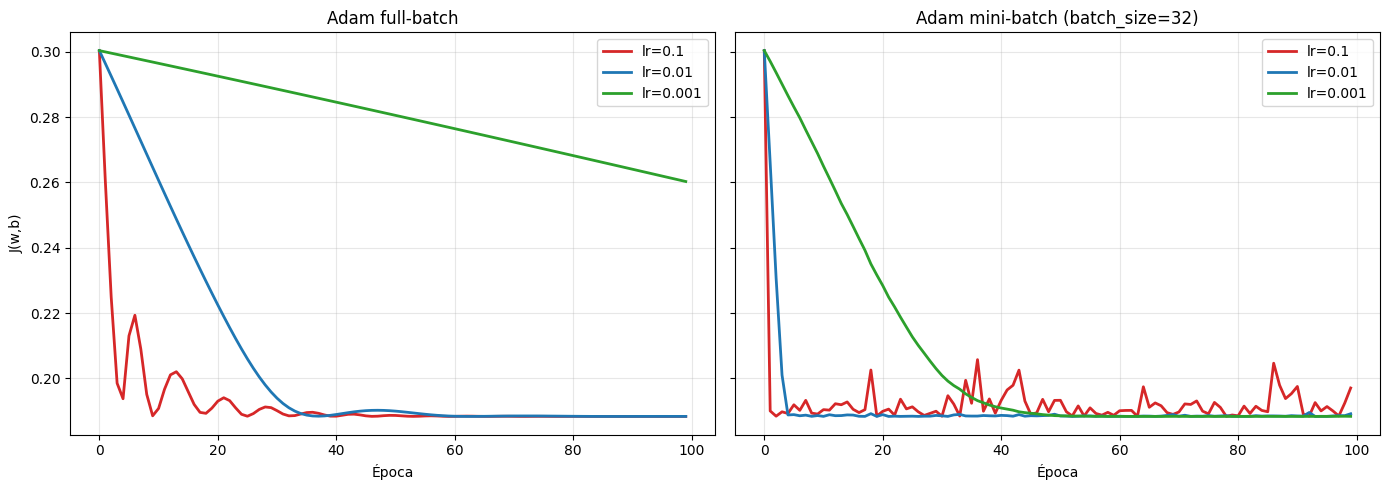

In [27]:
def adam_full_batch(lr, epochs=EPOCHS, beta1=0.9, beta2=0.999, eps=1e-8):
    w, b = w0, b0
    mw = vw = mb = vb = 0.0
    costs, ws, bs = [], [], []
    t = 0
    for _ in range(epochs):
        costs.append(cost_fn(w, b, x, y))
        ws.append(w); bs.append(b)
        t += 1
        dw, db = grad_fn(w, b, x, y)
        mw = beta1 * mw + (1 - beta1) * dw
        vw = beta2 * vw + (1 - beta2) * dw ** 2
        mb = beta1 * mb + (1 - beta1) * db
        vb = beta2 * vb + (1 - beta2) * db ** 2
        mw_hat, vw_hat = mw / (1 - beta1 ** t), vw / (1 - beta2 ** t)
        mb_hat, vb_hat = mb / (1 - beta1 ** t), vb / (1 - beta2 ** t)
        w -= lr * mw_hat / (np.sqrt(vw_hat) + eps)
        b -= lr * mb_hat / (np.sqrt(vb_hat) + eps)
    return np.array(costs), np.array(ws), np.array(bs), w, b


def adam_mini_batch(lr, epochs=EPOCHS, batch_size=32, beta1=0.9, beta2=0.999, eps=1e-8, seed=SEED):
    w, b = w0, b0
    mw = vw = mb = vb = 0.0
    costs, ws, bs = [], [], []
    t = 0
    local_rng = np.random.default_rng(seed)
    m = x.shape[0]
    for _ in range(epochs):
        costs.append(cost_fn(w, b, x, y))   # costo sobre TODO el dataset, para poder comparar contra full-batch
        ws.append(w); bs.append(b)
        perm = local_rng.permutation(m)
        for start in range(0, m, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = x[idx], y[idx]
            t += 1
            dw, db = grad_fn(w, b, xb, yb)
            mw = beta1 * mw + (1 - beta1) * dw
            vw = beta2 * vw + (1 - beta2) * dw ** 2
            mb = beta1 * mb + (1 - beta1) * db
            vb = beta2 * vb + (1 - beta2) * db ** 2
            mw_hat, vw_hat = mw / (1 - beta1 ** t), vw / (1 - beta2 ** t)
            mb_hat, vb_hat = mb / (1 - beta1 ** t), vb / (1 - beta2 ** t)
            w -= lr * mw_hat / (np.sqrt(vw_hat) + eps)
            b -= lr * mb_hat / (np.sqrt(vb_hat) + eps)
    return np.array(costs), np.array(ws), np.array(bs), w, b

BATCH_SIZE = 32
adam_full_hist, adam_mini_hist = {}, {}
for lr in LRS:
    costs, ws, bs, wf, bf = adam_full_batch(lr)
    adam_full_hist[lr] = dict(costs=costs, ws=ws, bs=bs, wf=wf, bf=bf)
    print(f"Adam full-batch lr={lr:<6} costo final={costs[-1]:.5f}  w={wf:.4f}  b={bf:.4f}")
for lr in LRS:
    costs, ws, bs, wf, bf = adam_mini_batch(lr, batch_size=BATCH_SIZE)
    adam_mini_hist[lr] = dict(costs=costs, ws=ws, bs=bs, wf=wf, bf=bf)
    print(f"Adam mini-batch lr={lr:<6} costo final={costs[-1]:.5f}  w={wf:.4f}  b={bf:.4f}")

# --- fin de la lógica de Adam, de acá para abajo es solo para graficar ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for lr in LRS:
    axes[0].plot(adam_full_hist[lr]["costs"], label=f"lr={lr}", color=COLORS[lr], linewidth=2)
axes[0].set_title("Adam full-batch"); axes[0].set_xlabel("Época"); axes[0].set_ylabel("J(w,b)")
axes[0].legend(); axes[0].grid(alpha=0.3)

for lr in LRS:
    axes[1].plot(adam_mini_hist[lr]["costs"], label=f"lr={lr}", color=COLORS[lr], linewidth=2)
axes[1].set_title(f"Adam mini-batch (batch_size={BATCH_SIZE})"); axes[1].set_xlabel("Época")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Con Adam full-batch, `lr=0.1` y `lr=0.01` también llegan al mismo piso que GD (~0.188), pero se nota que llegan más rápido (la pendiente inicial es más pronunciada). Tiene sentido: el segundo momento de Adam normaliza el paso según la magnitud reciente del gradiente, entonces puede dar pasos relativamente grandes en las zonas donde el gradiente es chico. Con `lr=0.001` tampoco converge del todo en 100 épocas (queda en 0.26), aunque le va algo mejor que a GD con el mismo lr.

Donde se ve la diferencia más marcada es en Adam mini-batch: incluso con `lr=0.001` termina convergiendo al piso dentro de las 100 épocas. Y la razón no es que el optimizador sea "mejor" en abstracto, sino algo bastante simple: con `batch_size=32` sobre 300 muestras hay 10 actualizaciones por época en vez de 1, entonces en 100 épocas mini-batch ya dio unos 1000 pasos de Adam contra apenas 100 de la versión full-batch. Es un detalle que conviene tener presente al comparar optimizadores full-batch contra mini-batch usando el eje de épocas, porque no representan la misma cantidad de trabajo de optimización.

### 1c) Comparativa de optimizadores (0.5 puntos)

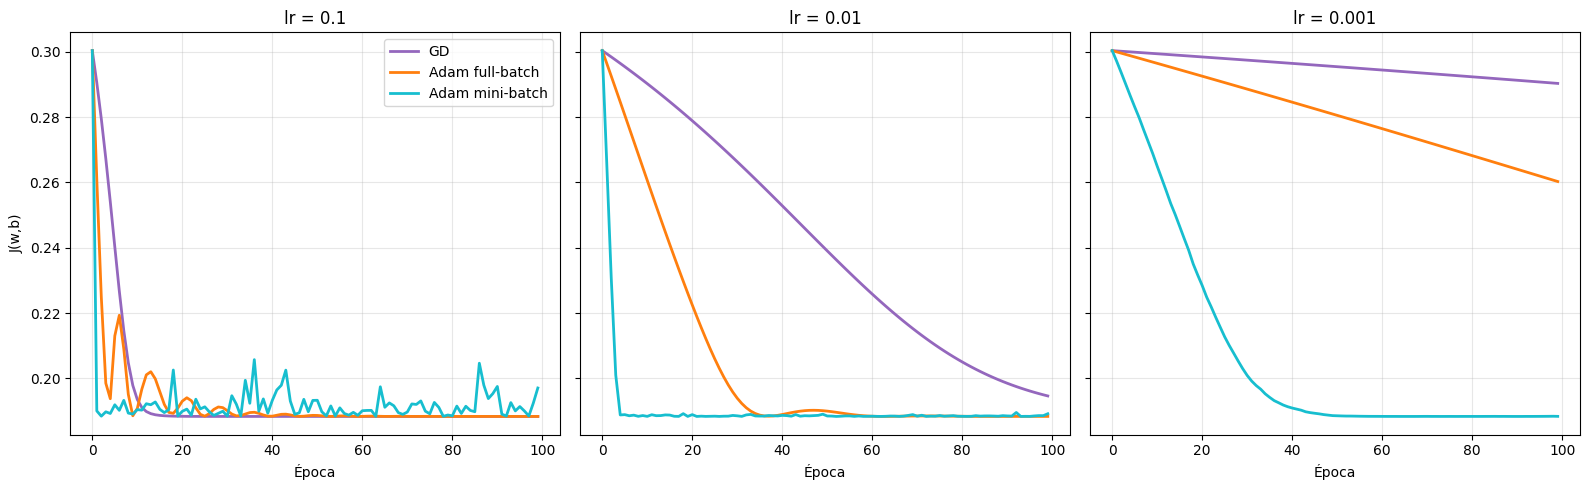

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, lr in zip(axes, LRS):
    ax.plot(gd_hist[lr]["costs"], label="GD", color="tab:purple", linewidth=2)
    ax.plot(adam_full_hist[lr]["costs"], label="Adam full-batch", color="tab:orange", linewidth=2)
    ax.plot(adam_mini_hist[lr]["costs"], label="Adam mini-batch", color="tab:cyan", linewidth=2)
    ax.set_title(f"lr = {lr}"); ax.set_xlabel("Época"); ax.grid(alpha=0.3)
axes[0].set_ylabel("J(w,b)"); axes[0].legend()
plt.tight_layout(); plt.show()

In [29]:
import pandas as pd

def epochs_to_converge(costs, thresh=0.198):
    idx = np.where(costs <= thresh)[0]
    return int(idx[0]) + 1 if len(idx) else None

rows = []
for lr in LRS:
    rows.append(["GD", lr, gd_hist[lr]["costs"][-1], epochs_to_converge(gd_hist[lr]["costs"])])
    rows.append(["Adam full-batch", lr, adam_full_hist[lr]["costs"][-1], epochs_to_converge(adam_full_hist[lr]["costs"])])
    rows.append(["Adam mini-batch", lr, adam_mini_hist[lr]["costs"][-1], epochs_to_converge(adam_mini_hist[lr]["costs"])])

tabla = pd.DataFrame(rows, columns=["Optimizador", "Learning rate", "Costo final (época 100)", "Época en la que J<=0.198"])
tabla["Costo final (época 100)"] = tabla["Costo final (época 100)"].round(5)
tabla

,Optimizador,Learning rate,Costo final (época 100),Época en la que J<=0.198
0,GD,0.100,0.18834,10.0
1,Adam full-batch,0.100,0.18834,5.0
2,Adam mini-batch,0.100,0.19705,2.0
3,GD,0.010,0.19461,92.0
4,Adam full-batch,0.010,0.18835,29.0
5,Adam mini-batch,0.010,0.18916,5.0
6,GD,0.001,0.29034,NaN
7,Adam full-batch,0.001,0.26029,NaN
8,Adam mini-batch,0.001,0.18836,33.0


Definimos que un optimizador "convergió" cuando el costo cae por debajo de 0.198 (un 5% por encima del piso de ~0.188 que alcanzan todas las combinaciones que llegan a buen puerto). Con esa referencia se ve un patrón bastante consistente: para `lr` grande o mediano el orden de velocidad es Adam mini-batch, después Adam full-batch, después GD. Con `lr=0.001`, GD y Adam full-batch no llegan a converger en 100 épocas, pero Adam mini-batch sí (recién en la época 33), simplemente porque hace 10 veces más actualizaciones por época.

En el costo final, cuando el `lr` es razonable (0.1 o 0.01) los tres optimizadores terminan prácticamente en el mismo lugar. La diferencia entre ellos en este problema no es tanto la calidad de la solución final, sino la velocidad para llegar y qué tan sensibles son a un `lr` mal elegido.

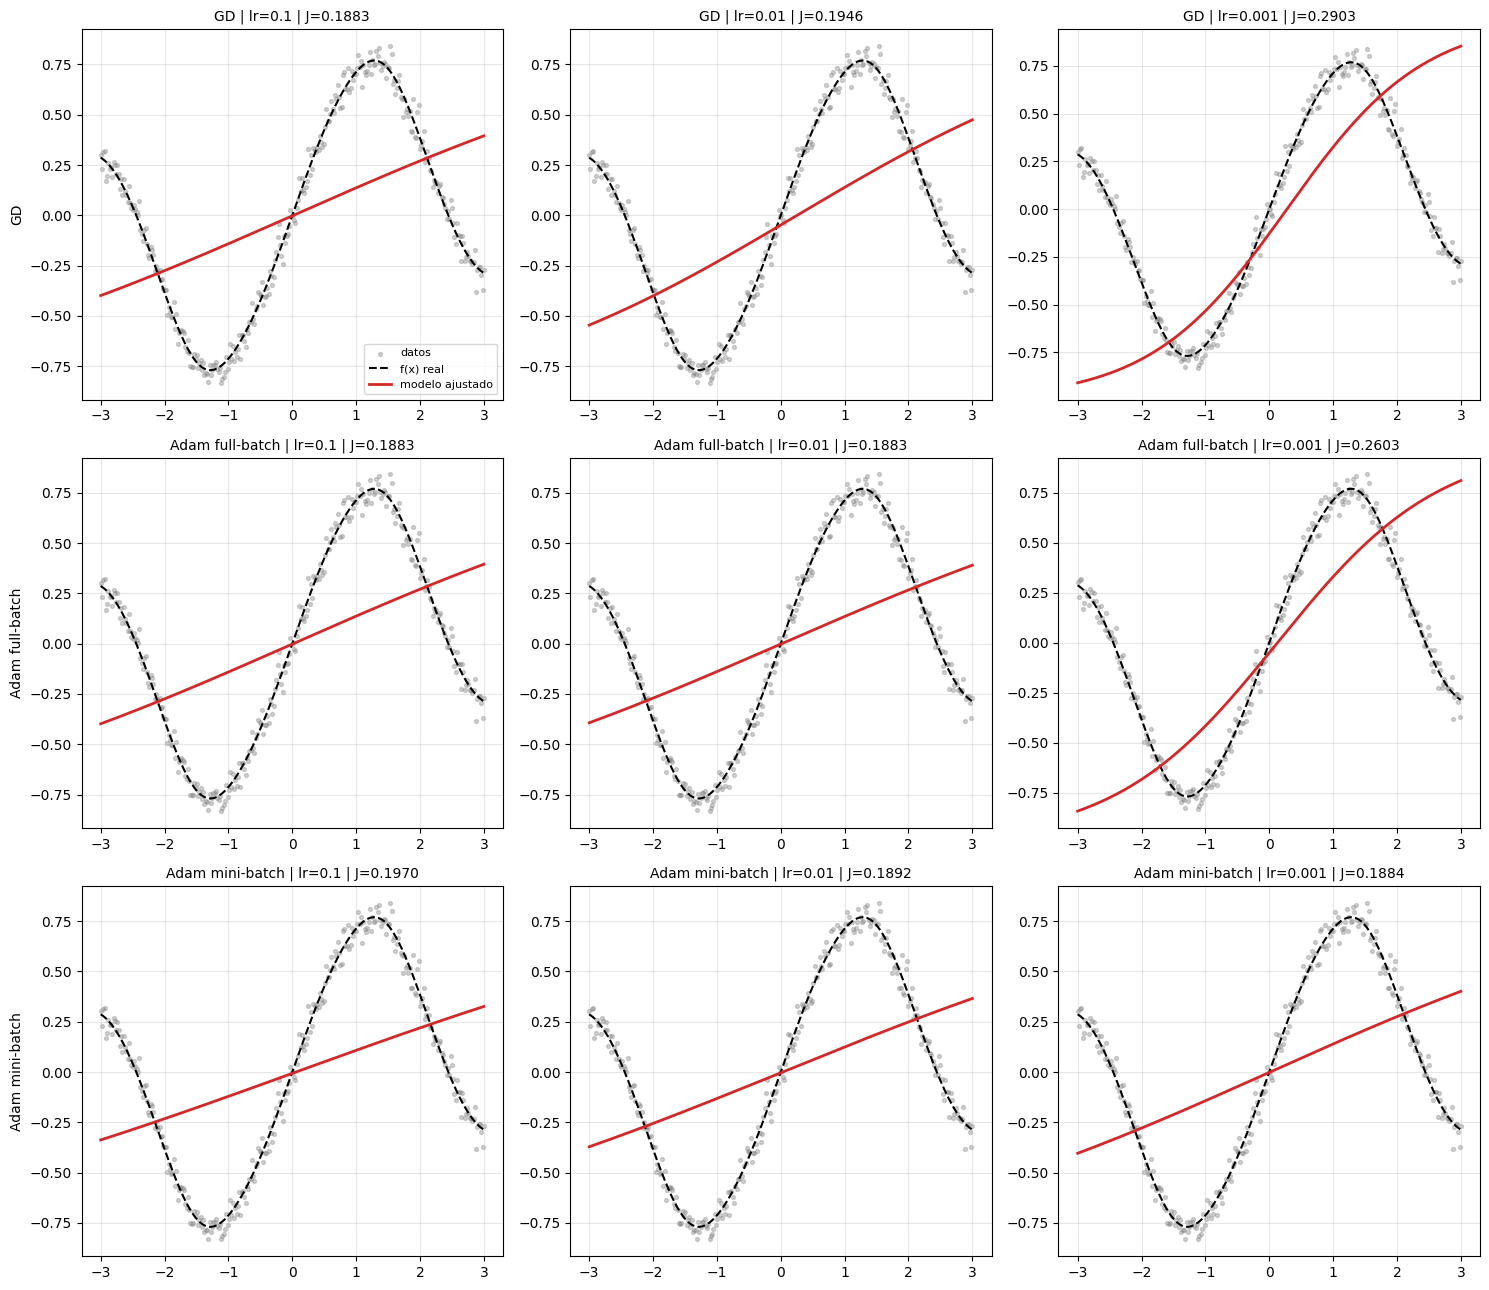

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
x_fine = np.linspace(x.min(), x.max(), 400)
optim_hists = {"GD": gd_hist, "Adam full-batch": adam_full_hist, "Adam mini-batch": adam_mini_hist}

for i, (name, hist) in enumerate(optim_hists.items()):
    for j, lr in enumerate(LRS):
        ax = axes[i, j]
        wf, bf = hist[lr]["wf"], hist[lr]["bf"]
        yhat_fine, _ = forward(wf, bf, x_fine)
        ax.scatter(x, y, s=8, alpha=0.35, color="gray", label="datos")
        ax.plot(x_fine, y_true_fn(x_fine), color="black", lw=1.5, ls="--", label="f(x) real")
        ax.plot(x_fine, yhat_fine, color="tab:red", lw=2, label="modelo ajustado")
        ax.set_title(f"{name} | lr={lr} | J={hist[lr]['costs'][-1]:.4f}", fontsize=10)
        if j == 0:
            ax.set_ylabel(name, fontsize=10)
        ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

En los 9 subplots se ve la limitación que ya comentamos al elegir el dataset: como la red es siempre monótona en $x$, nunca puede seguir las oscilaciones del seno, en el mejor caso encuentra una curva suave que pasa cerca del promedio de los datos. Esto se repite en todas las combinaciones que convergieron bien: el $w$ y el $b$ finales son parecidos entre optimizadores (se puede comparar con los valores impresos en 1a y 1b), porque todos están llegando al mismo mínimo, no es que uno "entienda" mejor el patrón que otro. Donde sí se nota una diferencia real es en las corridas con `lr=0.001` y GD o Adam full-batch: ahí la curva ajustada queda visiblemente más lejos del promedio de los datos porque el entrenamiento no llegó a converger.

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)

Elegimos `lr=0.001` para esta visualización porque es la combinación donde más se nota la diferencia de comportamiento entre optimizadores (ver 1c). Con learning rates más grandes los tres llegan casi enseguida al mínimo y las trayectorias quedarían superpuestas, no se distinguiría mucho en el gráfico 3D.

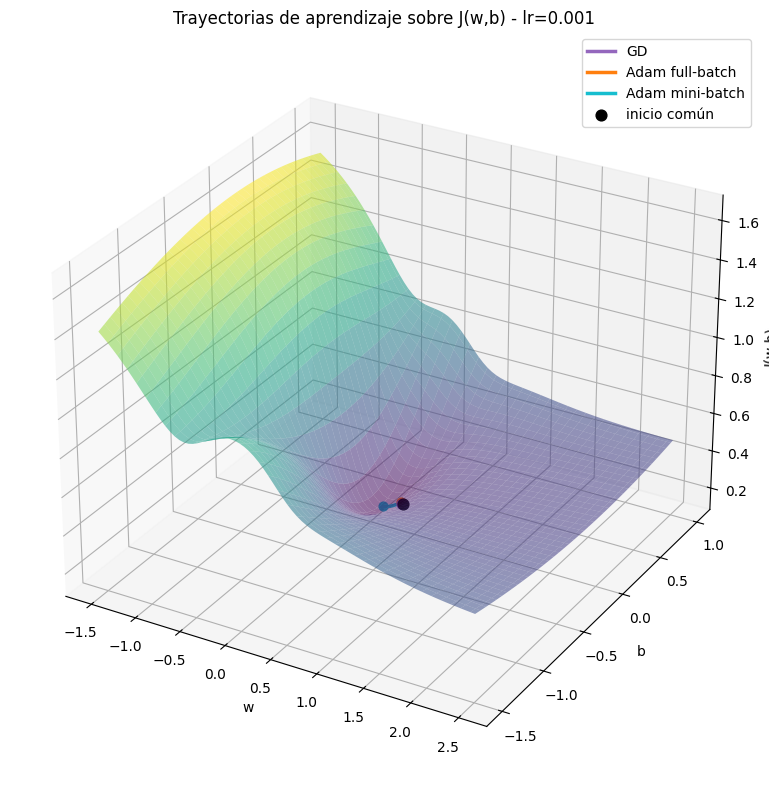

In [31]:
w_range = np.linspace(-1.5, 2.5, 80)
b_range = np.linspace(-1.5, 1.0, 80)
W, B = np.meshgrid(w_range, b_range)
J = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J[i, j] = cost_fn(W[i, j], B[i, j], x, y)

lr_3d = 0.001
traj = {
    "GD": (gd_hist[lr_3d]["ws"], gd_hist[lr_3d]["bs"], gd_hist[lr_3d]["costs"], "tab:purple"),
    "Adam full-batch": (adam_full_hist[lr_3d]["ws"], adam_full_hist[lr_3d]["bs"], adam_full_hist[lr_3d]["costs"], "tab:orange"),
    "Adam mini-batch": (adam_mini_hist[lr_3d]["ws"], adam_mini_hist[lr_3d]["bs"], adam_mini_hist[lr_3d]["costs"], "tab:cyan"),
}

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W, B, J, cmap="viridis", alpha=0.55, linewidth=0, antialiased=True)

for name, (ws, bs, costs, color) in traj.items():
    ax.plot(ws, bs, costs, color=color, linewidth=2.5, label=name)
    ax.scatter(ws[-1], bs[-1], costs[-1], color=color, s=40)
ax.scatter([w0], [b0], [cost_fn(w0, b0, x, y)], color="black", s=60, label="inicio común")

ax.set_xlabel("w"); ax.set_ylabel("b"); ax.set_zlabel("J(w,b)")
ax.set_title(f"Trayectorias de aprendizaje sobre J(w,b) - lr={lr_3d}")
ax.view_init(elev=28, azim=-60)
ax.legend()
plt.tight_layout(); plt.show()

Las tres trayectorias arrancan del mismo punto sobre la superficie de $J(w,b)$, que es no convexa: hay curvaturas distintas según la dirección y una zona bastante plana lejos del mínimo. Ahí es donde se nota la diferencia entre optimizadores.

GD (violeta) avanza con pasos cortos, más o menos proporcionales al gradiente local, así que en la zona plana casi no se mueve. Al terminar las 100 épocas todavía le queda camino para llegar al valle.

Adam full-batch (naranja) recorre más distancia en el mismo número de épocas: como normaliza el paso según el historial del gradiente, en las zonas planas donde GD casi no avanza, Adam sí da pasos más grandes. Aun así, con un solo paso por época no llega tan cerca del mínimo como mini-batch.

Adam mini-batch (cian) es la que más avanza sobre la superficie. No es que "vea" mejor la forma de la superficie, sino que da unos 10 pasos de Adam por cada época mientras que las otras dos dan solo uno.

En resumen, en este problema Adam ayuda sobre todo a no quedarse pegado en las zonas chatas de la superficie de costo, y mini-batch multiplica directamente la cantidad de pasos que se dan en el mismo número de épocas.

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

## Objetivo del caso de estudio

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. El modelo debe predecir el gasto promedio **por cliente**, no el gasto de cada transacción individual, y debe poder aplicarse luego a clientes relativamente nuevos, que solo llevan entre 3 y 5 visitas y compras en la tienda.

### 2a) EDA y preparación del dataset (2 puntos)

In [32]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_ID = "1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ"
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", "dataset.csv", quiet=False)

df = pd.read_csv("dataset.csv")
print("Shape:", df.shape)
df.head()

Downloading...
From: https://drive.google.com/uc?id=1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ
To: /content/dataset.csv
100%|██████████| 8.41M/8.41M [00:00<00:00, 80.7MB/s]


Shape: (182721, 11)


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


In [33]:
df.info()
print()
print("Nulos por columna:")
print(df.isnull().sum())
print()
print("Usuarios únicos:", df['User_ID'].nunique(), " | Productos únicos:", df['Product_ID'].nunique())
print()
print(df['Purchase'].describe())
print("Purchase skew:", df['Purchase'].skew())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  object 
 2   Age                         182721 non-null  object 
 3   Gender                      182721 non-null  object 
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  object 
 6   Stay_In_Current_City_Years  182721 non-null  object 
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 15.3+ MB

Nulos por columna:
User_ID                            0
Product_ID     

El dataset tiene 182.721 transacciones de 7.432 usuarios distintos sobre 2.455 productos. Hay dos columnas con bastantes nulos: `Product_Subcategory_1` (23%) y `Product_Subcategory_2` (58%). `Purchase` (el monto por transacción) tiene sesgo positivo moderado (skew≈1.1), la mayoría de las transacciones son de monto bajo con una cola de compras más caras.

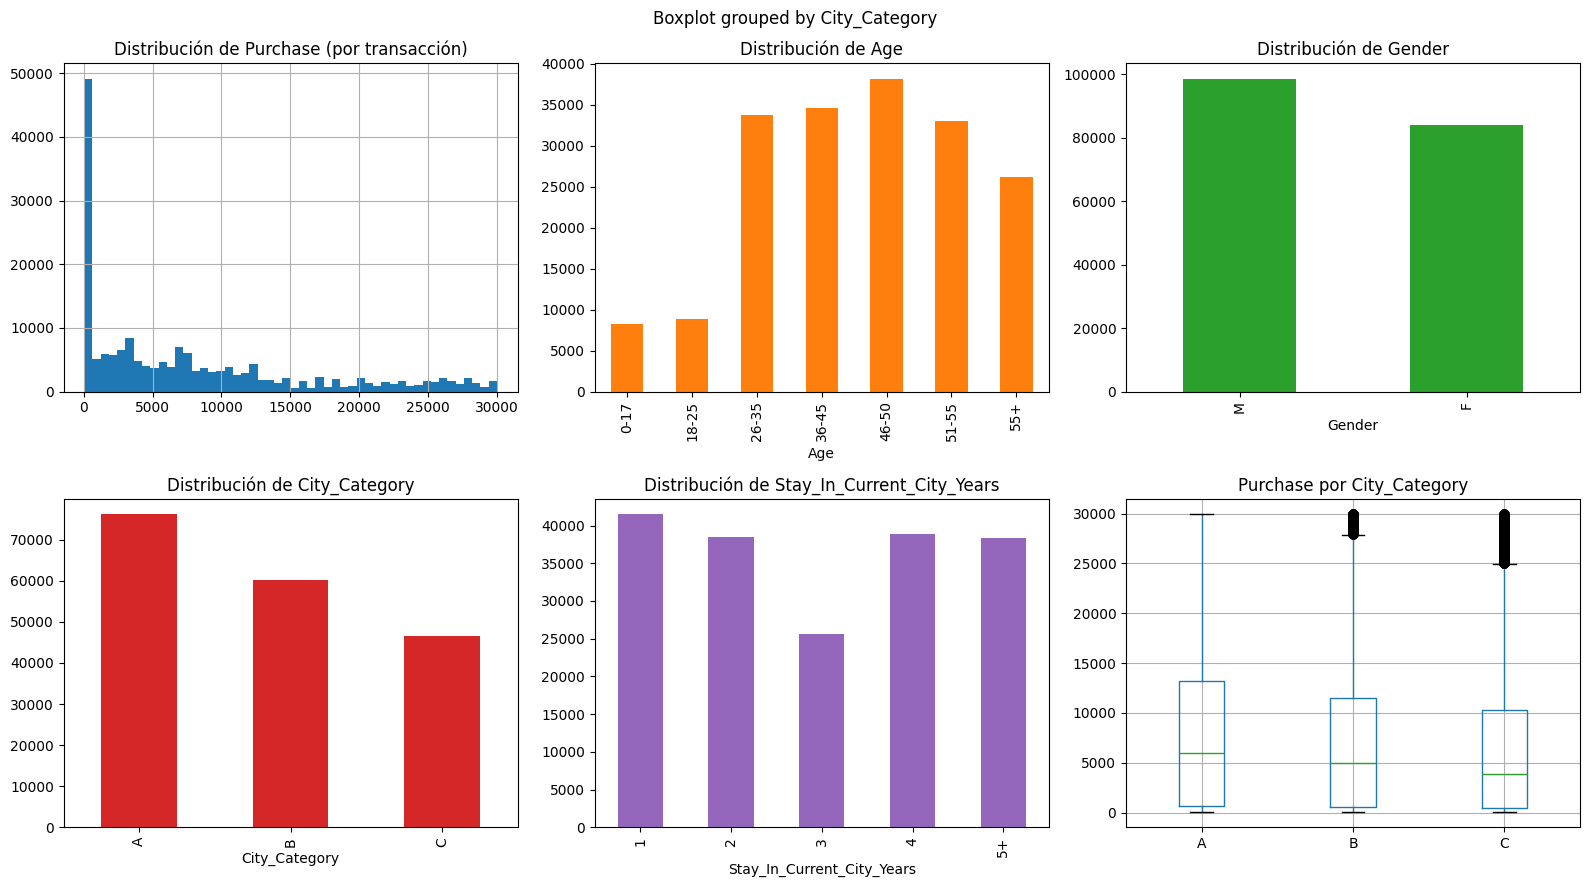

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

df['Purchase'].hist(bins=50, ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("Distribución de Purchase (por transacción)")

df['Age'].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1], color="tab:orange")
axes[0, 1].set_title("Distribución de Age")

df['Gender'].value_counts().plot(kind="bar", ax=axes[0, 2], color="tab:green")
axes[0, 2].set_title("Distribución de Gender")

df['City_Category'].value_counts().plot(kind="bar", ax=axes[1, 0], color="tab:red")
axes[1, 0].set_title("Distribución de City_Category")

df['Stay_In_Current_City_Years'].value_counts().sort_index().plot(kind="bar", ax=axes[1, 1], color="tab:purple")
axes[1, 1].set_title("Distribución de Stay_In_Current_City_Years")

df.boxplot(column="Purchase", by="City_Category", ax=axes[1, 2])
axes[1, 2].set_title("Purchase por City_Category"); axes[1, 2].set_xlabel("")

plt.tight_layout(); plt.show()

In [35]:
demo_cols = ["Age", "Gender", "Marital_Status", "City_Category", "Stay_In_Current_City_Years"]
print("Usuarios con más de 1 valor distinto en cada columna demográfica:")
for col in demo_cols:
    n_inconsistentes = (df.groupby("User_ID")[col].nunique() > 1).sum()
    print(f"  {col:28s}: {n_inconsistentes} de {df['User_ID'].nunique()}")

txn_per_user = df.groupby("User_ID").size()
print()
print("Transacciones por usuario:")
print(txn_per_user.describe())

Usuarios con más de 1 valor distinto en cada columna demográfica:
  Age                         : 0 de 7432
  Gender                      : 0 de 7432
  Marital_Status              : 0 de 7432
  City_Category               : 0 de 7432
  Stay_In_Current_City_Years  : 0 de 7432

Transacciones por usuario:
count    7432.000000
mean       24.585710
std        13.686571
min        10.000000
25%        14.000000
50%        18.000000
75%        40.000000
max        50.000000
dtype: float64


**Qué usamos y qué no.**

`User_ID` lo usamos solo para agrupar las transacciones de cada cliente, que es la unidad que nos interesa (no la transacción). No lo metemos como feature porque es un identificador sin ningún significado, sería puro ruido. Con `Product_ID` pasa algo parecido: hay 2.455 productos distintos, demasiados para codificarlo directamente, así que solo lo usamos para contar cuántos productos distintos compró cada cliente, no para identificar cuáles.

`Product_Subcategory_1` y `Product_Subcategory_2` las sacamos. La segunda tiene 58% de nulos, no hay una categoría "vacía" razonable para imputar ahí y agregaría más ruido que información. La primera tiene 23% de nulos y en teoría se podría rescatar, pero la info de categoría de producto ya la tenemos completa (0% nulos) en `Product_Category`, así que preferimos usar esa y no sumar ruido de imputación.

Las columnas demográficas (`Age`, `Gender`, `Marital_Status`, `City_Category`, `Stay_In_Current_City_Years`) las chequeamos arriba y son constantes por usuario (ningún usuario tiene más de un valor distinto), o sea que son atributos del cliente y no de la transacción, y se pueden llevar directo al dataset por cliente.

Para los encodings: `Age` es ordinal (los rangos de edad tienen un orden natural), la codificamos como 0 a 6 en vez de one-hot para no perder ese orden. `Stay_In_Current_City_Years` es lo mismo, la mapeamos a enteros del 1 al 5 (`"5+"` -> 5). `Gender` es binaria (F=0, M=1). `Marital_Status` ya viene en 0/1. `City_Category` en cambio es nominal (A, B y C no tienen un orden de magnitud entre sí), así que ahí sí usamos one-hot, con `drop_first=True` para no generar colinealidad perfecta.

Ahora, el punto que nos pareció más importante de esta sección. El objetivo dice que el modelo se va a aplicar a clientes nuevos que solo tienen 3 a 5 visitas. Si armamos las features agregando todo el historial anual de cada cliente (por ejemplo, cuántas transacciones hizo en total en el año, o en qué mezcla de categorías compró durante todo ese tiempo), estaríamos usando información que un cliente nuevo todavía no generó. No es el leakage típico de "usar el target como feature", pero el problema de fondo es parecido: el modelo terminaría dependiendo de datos que, para el tipo de cliente que nos interesa, todavía no existen en el momento de predecir.

Lo comprobamos con un experimento chico: construimos el mismo target (gasto promedio) con dos formas distintas de armar las features de comportamiento.

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

target = df.groupby("User_ID")["Purchase"].mean().rename("avg_purchase")
demo = df.groupby("User_ID").agg({"Age": "first", "Gender": "first", "Marital_Status": "first",
                                   "City_Category": "first", "Stay_In_Current_City_Years": "first"}).reset_index()

age_order = ["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]

def encode_demo(data):
    out = data.copy()
    out["Age_ord"] = out["Age"].map({a: i for i, a in enumerate(age_order)})
    out["Gender_bin"] = out["Gender"].map({"F": 0, "M": 1})
    out["Stay_ord"] = out["Stay_In_Current_City_Years"].replace("5+", "5").astype(int)
    city_dum = pd.get_dummies(out["City_Category"], prefix="City", drop_first=True).astype(int)
    return pd.concat([out[["User_ID", "Age_ord", "Gender_bin", "Marital_Status", "Stay_ord"]], city_dum], axis=1)

# (A) features agregadas sobre TODO el historial anual
cat_counts_full = pd.crosstab(df["User_ID"], df["Product_Category"]).add_prefix("cat_")
n_txn = df.groupby("User_ID").size().rename("n_transactions")
n_prod = df.groupby("User_ID")["Product_ID"].nunique().rename("n_unique_products")
n_cat = df.groupby("User_ID")["Product_Category"].nunique().rename("n_unique_categories")

data_A = encode_demo(demo).merge(cat_counts_full, on="User_ID").merge(n_txn, on="User_ID") \
                            .merge(n_prod, on="User_ID").merge(n_cat, on="User_ID").merge(target, on="User_ID")
X_A = data_A.drop(columns=["User_ID", "avg_purchase"])
y_A = data_A["avg_purchase"].values

Xtr, Xva, ytr, yva = train_test_split(X_A, y_A, test_size=0.2, random_state=42)
sc = StandardScaler().fit(Xtr)
lr_model = LinearRegression().fit(sc.transform(Xtr), ytr)
r2_naive = r2_score(yva, lr_model.predict(sc.transform(Xva)))
print(f"(A) features con historial completo: R2 val = {r2_naive:.4f}")

(A) features con historial completo: R2 val = 0.8728


In [37]:
# (B) simulamos que solo conocemos 3 a 5 visitas por cliente, como un cliente nuevo
SEED = 42
rng = np.random.default_rng(SEED)
all_categories = sorted(df["Product_Category"].unique())

records = []
for uid, g in df.groupby("User_ID"):
    k = int(rng.integers(3, 6))          # 3, 4 o 5 visitas conocidas
    k = min(k, len(g))
    sample = g.sample(n=k, random_state=int(uid) % (2**32 - 1))
    row = {"User_ID": uid, "n_sampled_visits": k,
           "n_sampled_products": sample["Product_ID"].nunique(),
           "n_sampled_categories": sample["Product_Category"].nunique()}
    vc = sample["Product_Category"].value_counts()
    for c in all_categories:
        row[f"cat_{c}"] = int(vc.get(c, 0))
    records.append(row)
behav_honest = pd.DataFrame(records)

data_B = encode_demo(demo).merge(behav_honest, on="User_ID").merge(target, on="User_ID")
X_B = data_B.drop(columns=["User_ID", "avg_purchase"])
y_B = data_B["avg_purchase"].values

Xtr, Xva, ytr, yva = train_test_split(X_B, y_B, test_size=0.2, random_state=42)
sc = StandardScaler().fit(Xtr)
lr_model_b = LinearRegression().fit(sc.transform(Xtr), ytr)
r2_honest = r2_score(yva, lr_model_b.predict(sc.transform(Xva)))
print(f"(B) features con solo 3-5 visitas simuladas: R2 val = {r2_honest:.4f}")

(B) features con solo 3-5 visitas simuladas: R2 val = 0.5523


El enfoque (A) da un R2 altísimo (0.87), pero es medio un espejismo: para lograrlo el modelo se apoya mucho en la cantidad total de transacciones del año, un dato que un cliente con 3-5 visitas todavía no tiene. Ese modelo en el fondo termina resolviendo otro problema, no el que pide la consigna.

El enfoque (B) en cambio usa solo lo que un cliente nuevo sí tendría disponible: sus datos demográficos y un pantallazo de sus primeras compras. El R2 baja bastante (0.55 con una regresión lineal simple), pero es la estimación honesta de lo que se puede lograr en el escenario real de negocio. De acá en adelante usamos el enfoque (B) para entrenar la red en 2b.

In [38]:
final_df = data_B.copy()
feature_cols = [c for c in final_df.columns if c not in ("User_ID", "avg_purchase")]
print("Cantidad de features finales:", len(feature_cols))
print(feature_cols)
final_df.describe()

Cantidad de features finales: 29
['Age_ord', 'Gender_bin', 'Marital_Status', 'Stay_ord', 'City_B', 'City_C', 'n_sampled_visits', 'n_sampled_products', 'n_sampled_categories', 'cat_1', 'cat_2', 'cat_3', 'cat_4', 'cat_5', 'cat_6', 'cat_7', 'cat_8', 'cat_9', 'cat_10', 'cat_11', 'cat_12', 'cat_13', 'cat_14', 'cat_15', 'cat_16', 'cat_17', 'cat_18', 'cat_19', 'cat_20']


,User_ID,Age_ord,Gender_bin,Marital_Status,Stay_ord,City_B,City_C,n_sampled_visits,n_sampled_products,n_sampled_categories,...,cat_12,cat_13,cat_14,cat_15,cat_16,cat_17,cat_18,cat_19,cat_20,avg_purchase
count,7.432000e+03,7432.000000,7432.000000,7432.000000,7432.000000,7432.000000,7432.000000,7432.000000,7432.000000,7432.000000,...,7432.000000,7432.000000,7432.000000,7432.000000,7432.000000,7432.000000,7432.000000,7432.00000,7432.000000,7432.000000
mean,1.049772e+06,3.368541,0.524892,0.593380,2.626211,0.338267,0.273816,3.986006,3.982508,3.569699,...,0.263052,0.127557,0.126346,0.183665,0.304763,0.346609,0.128767,0.13711,0.150296,6749.655185
std,2.883203e+04,1.757218,0.499414,0.491236,1.425757,0.473152,0.445946,0.819010,0.819600,0.846271,...,0.508934,0.360750,0.357243,0.435953,0.540228,0.580620,0.363481,0.37898,0.392213,3297.891670
min,1.000035e+06,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,275.272727
25%,1.024772e+06,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3.000000,3.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,4247.395833
50%,1.049775e+06,3.000000,1.000000,1.000000,2.000000,0.000000,0.000000,4.000000,4.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,6330.212766
75%,1.074651e+06,5.000000,1.000000,1.000000,4.000000,1.000000,1.000000,5.000000,5.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.00000,0.000000,8519.184470
max,1.099995e+06,6.000000,1.000000,1.000000,5.000000,1.000000,1.000000,5.000000,5.000000,5.000000,...,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.00000,3.000000,17231.138889


### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)

In [39]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

torch.manual_seed(SEED)

X = final_df[feature_cols].values.astype(np.float32)
y = final_df["avg_purchase"].values.astype(np.float32).reshape(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED)

x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train)   # estandarizamos el target para que el entrenamiento sea más estable, no afecta el R2

Xtr_t = torch.tensor(x_scaler.transform(X_train), dtype=torch.float32)
Xva_t = torch.tensor(x_scaler.transform(X_val), dtype=torch.float32)
ytr_t = torch.tensor(y_scaler.transform(y_train), dtype=torch.float32)
yva_t = torch.tensor(y_scaler.transform(y_val), dtype=torch.float32)

train_ds = TensorDataset(Xtr_t, ytr_t)
print("Train:", Xtr_t.shape, " Val:", Xva_t.shape)

Train: torch.Size([5945, 29])  Val: torch.Size([1487, 29])


Antes de fijar la arquitectura probamos algunas variantes del mismo MLP base (3 capas ocultas, mínimo 32 neuronas por capa, como pide la consigna) y comparamos el R2 de validación. No es una grilla exhaustiva, son unas pocas pruebas para no elegir todo "a ojo".

In [40]:
def make_mlp(in_dim, hidden, activation, dropout=0.0):
    acts = {"relu": nn.ReLU, "tanh": nn.Tanh}
    Act = acts[activation]
    layers, prev = [], in_dim
    for h in hidden:
        layers += [nn.Linear(prev, h), Act()]
        if dropout > 0:
            layers += [nn.Dropout(dropout)]
        prev = h
    layers += [nn.Linear(prev, 1)]
    return nn.Sequential(*layers)

def train_eval(hidden, activation, lr, epochs, batch_size=None, dropout=0.0, seed=SEED):
    torch.manual_seed(seed)
    model = make_mlp(Xtr_t.shape[1], hidden, activation, dropout)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    val_r2s, val_losses, train_losses = [], [], []
    if batch_size is None:
        for epoch in range(epochs):
            model.train(); opt.zero_grad()
            loss = loss_fn(model(Xtr_t), ytr_t); loss.backward(); opt.step()
            model.eval()
            with torch.no_grad():
                vpred = model(Xva_t)
                val_losses.append(loss_fn(vpred, yva_t).item())
                val_r2s.append(r2_score(yva_t.numpy(), vpred.numpy()))
                train_losses.append(loss.item())
    else:
        loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        for epoch in range(epochs):
            model.train()
            ep_losses = []
            for xb, yb in loader:
                opt.zero_grad()
                loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
                ep_losses.append(loss.item())
            model.eval()
            with torch.no_grad():
                vpred = model(Xva_t)
                val_losses.append(loss_fn(vpred, yva_t).item())
                val_r2s.append(r2_score(yva_t.numpy(), vpred.numpy()))
                train_losses.append(float(np.mean(ep_losses)))
    return model, train_losses, val_losses, val_r2s

print("activación (hidden=[64,64,32], lr=1e-3, full-batch, 150 épocas):")
for act in ["relu", "tanh"]:
    _, tl, vl, vr2 = train_eval([64, 64, 32], act, 1e-3, 150)
    print(f"  {act:6s} R2 final={vr2[-1]:.4f}  mejor={max(vr2):.4f}")

print()
print("learning rate (relu, full-batch, 150 épocas):")
for lr_test in [0.1, 0.01, 0.001, 0.0005]:
    _, tl, vl, vr2 = train_eval([64, 64, 32], "relu", lr_test, 150)
    print(f"  lr={lr_test:<8} R2 final={vr2[-1]:.4f}  mejor={max(vr2):.4f}")

print()
print("dropout + mini-batch (tanh, lr=1e-3, batch_size=128, 150 épocas):")
for dropout_test in [0.0, 0.1, 0.2, 0.3]:
    _, tl, vl, vr2 = train_eval([64, 64, 32], "tanh", 1e-3, 150, batch_size=128, dropout=dropout_test)
    best_ep = int(np.argmax(vr2))
    print(f"  dropout={dropout_test} mejor R2={vr2[best_ep]:.4f} (época {best_ep})  R2 final={vr2[-1]:.4f}")

activación (hidden=[64,64,32], lr=1e-3, full-batch, 150 épocas):
  relu   R2 final=0.5466  mejor=0.5573
  tanh   R2 final=0.5562  mejor=0.5562

learning rate (relu, full-batch, 150 épocas):
  lr=0.1      R2 final=0.5533  mejor=0.5533
  lr=0.01     R2 final=0.3563  mejor=0.5622
  lr=0.001    R2 final=0.5466  mejor=0.5573
  lr=0.0005   R2 final=0.5545  mejor=0.5545

dropout + mini-batch (tanh, lr=1e-3, batch_size=128, 150 épocas):
  dropout=0.0 mejor R2=0.5858 (época 23)  R2 final=0.3780
  dropout=0.1 mejor R2=0.5945 (época 72)  R2 final=0.5688
  dropout=0.2 mejor R2=0.5871 (época 101)  R2 final=0.5783
  dropout=0.3 mejor R2=0.5847 (época 134)  R2 final=0.5838


De esto nos quedamos con `tanh` en vez de `relu`: da un R2 un poco mejor y sobre todo más estable. Con tan pocos datos (unos 6000 usuarios de entrenamiento) y una red relativamente ancha para ese volumen, `relu` puede terminar con neuronas "muertas" (gradiente cero para entradas negativas), algo que `tanh` evita al ser una función suave centrada en 0.

Como optimizador usamos Adam, por la misma razón que en la Pregunta 1: adapta el paso por parámetro según el historial del gradiente, y en este caso las columnas `cat_*` son mayormente ceros mezcladas con features demográficas densas, así que hay gradientes de magnitudes bastante distintas entre columnas, justo el escenario donde Adam rinde mejor que un GD de paso fijo.

Para el learning rate probamos 0.1, 0.01, 0.001 y 0.0005: con 0.1 el R2 final termina peor que el mejor valor que alcanzó durante el entrenamiento (como si se pasara de largo del mínimo), y entre 0.001 y 0.0005 el resultado es casi el mismo. Nos quedamos con `1e-3`.

El dropout fue el cambio que más ayudó. Sin él, el pico de R2 se alcanza rápido y después se derrumba si se sigue entrenando (se ve en la corrida con `dropout=0.0` de arriba). Con `dropout=0.2` el pico es prácticamente el mismo pero se mantiene mucho más estable en las épocas siguientes, que es justo lo que se espera de una regularización: no sube el techo, pero ayuda a no perderlo.

Para el batch probamos 32, 64, 128 y 256; con 128 el entrenamiento se ve más estable (con batches más chicos hay más ruido en el gradiente porque buena parte de las columnas `cat_*` son ceros). La arquitectura la dejamos en 3 capas de 64, 64 y 32 neuronas, que cumple el mínimo pedido; probamos algo más ancho y no mejoró nada, con este volumen de datos solo suma parámetros de más para sobreajustar. Y usamos MSE como función de costo, la elección estándar para regresión y coherente con el R2 que se pide como métrica.

In [41]:
FINAL_HIDDEN = [64, 64, 32]
FINAL_ACTIVATION = "tanh"
FINAL_LR = 1e-3
FINAL_DROPOUT = 0.2
FINAL_BATCH_SIZE = 128
FINAL_EPOCHS = 150

_, _, _, val_r2s_check = train_eval(
    FINAL_HIDDEN, FINAL_ACTIVATION, FINAL_LR, FINAL_EPOCHS,
    batch_size=FINAL_BATCH_SIZE, dropout=FINAL_DROPOUT, seed=SEED,
)
print(f"config final -> mejor época: {int(np.argmax(val_r2s_check))}  R2 val = {max(val_r2s_check):.4f}")
print(f"config final -> última época ({FINAL_EPOCHS}): R2 val = {val_r2s_check[-1]:.4f}")
# el entrenamiento completo con las curvas de train y validation se repite en 2c

config final -> mejor época: 101  R2 val = 0.5871
config final -> última época (150): R2 val = 0.5783


### 2c) Evaluación del Modelo (1 punto)

Para graficar train y validation juntos repetimos el entrenamiento, esta vez guardando también las métricas de train en cada época (arriba solo guardamos las de validación para no repetir código en la búsqueda de hiperparámetros).

Mejor época: 101  R2 val = 0.5871
Época final (150): R2 val = 0.5783


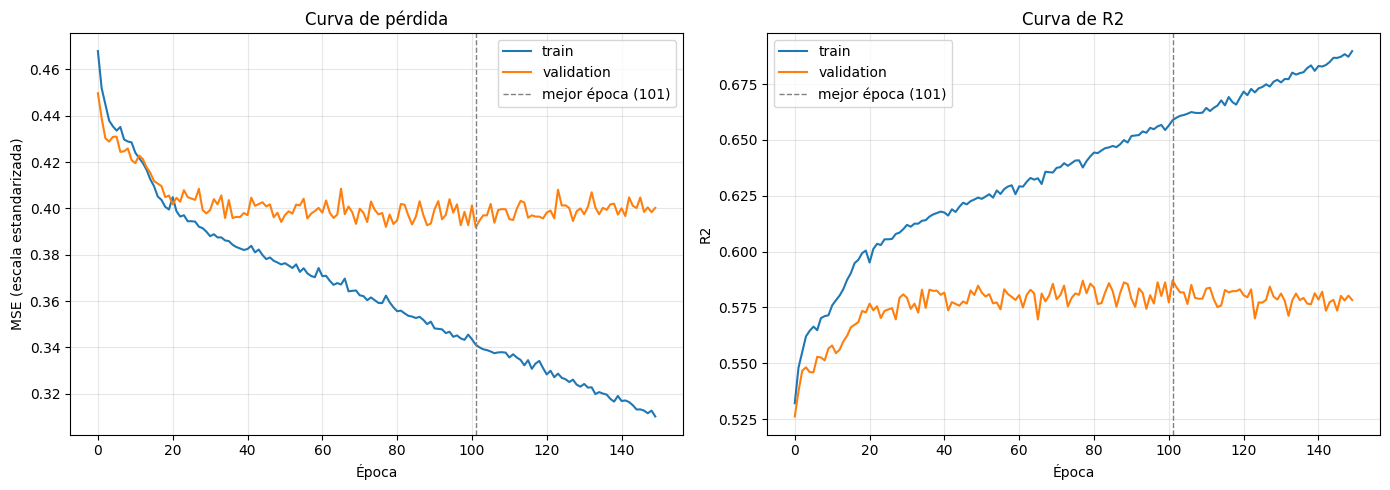

In [42]:
torch.manual_seed(SEED)
model = make_mlp(Xtr_t.shape[1], FINAL_HIDDEN, FINAL_ACTIVATION, FINAL_DROPOUT)
opt = torch.optim.Adam(model.parameters(), lr=FINAL_LR)
loss_fn = nn.MSELoss()
loader = DataLoader(train_ds, batch_size=FINAL_BATCH_SIZE, shuffle=True)

history = {"train_loss": [], "val_loss": [], "train_r2": [], "val_r2": []}
for epoch in range(FINAL_EPOCHS):
    model.train()
    for xb, yb in loader:
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        tr_pred = model(Xtr_t)
        va_pred = model(Xva_t)
        history["train_loss"].append(loss_fn(tr_pred, ytr_t).item())
        history["val_loss"].append(loss_fn(va_pred, yva_t).item())
        history["train_r2"].append(r2_score(ytr_t.numpy(), tr_pred.numpy()))
        history["val_r2"].append(r2_score(yva_t.numpy(), va_pred.numpy()))

best_epoch = int(np.argmax(history["val_r2"]))
print(f"Mejor época: {best_epoch}  R2 val = {history['val_r2'][best_epoch]:.4f}")
print(f"Época final ({FINAL_EPOCHS}): R2 val = {history['val_r2'][-1]:.4f}")

# --- fin del entrenamiento, de acá para abajo es solo para graficar ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="train", color="tab:blue")
axes[0].plot(history["val_loss"], label="validation", color="tab:orange")
axes[0].axvline(best_epoch, color="gray", ls="--", lw=1, label=f"mejor época ({best_epoch})")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE (escala estandarizada)")
axes[0].set_title("Curva de pérdida"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["train_r2"], label="train", color="tab:blue")
axes[1].plot(history["val_r2"], label="validation", color="tab:orange")
axes[1].axvline(best_epoch, color="gray", ls="--", lw=1, label=f"mejor época ({best_epoch})")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("R2")
axes[1].set_title("Curva de R2"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

R2 (validación, escala real $) = 0.5783
MAE  = $1,624.12
RMSE = $2,096.71
Promedio real del target (val) = $6,649.97  |  desvío = $3,228.86


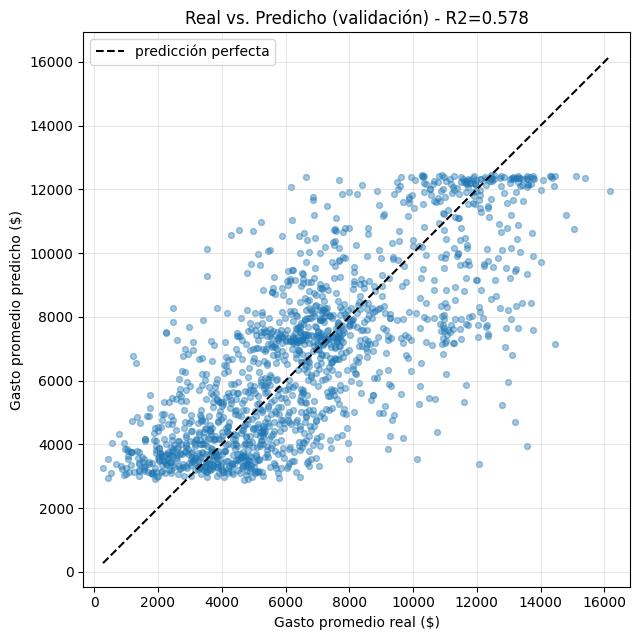

In [43]:
model.eval()
with torch.no_grad():
    val_pred_std = model(Xva_t).numpy()
val_pred = y_scaler.inverse_transform(val_pred_std)
val_true = y_val

r2_final = r2_score(val_true, val_pred)
mae_final = mean_absolute_error(val_true, val_pred)
rmse_final = np.sqrt(mean_squared_error(val_true, val_pred))

print(f"R2 (validación, escala real $) = {r2_final:.4f}")
print(f"MAE  = ${mae_final:,.2f}")
print(f"RMSE = ${rmse_final:,.2f}")
print(f"Promedio real del target (val) = ${val_true.mean():,.2f}  |  desvío = ${val_true.std():,.2f}")

plt.figure(figsize=(6.5, 6.5))
lims = [min(val_true.min(), val_pred.min()), max(val_true.max(), val_pred.max())]
plt.scatter(val_true, val_pred, alpha=0.4, s=18, color="tab:blue")
plt.plot(lims, lims, color="black", ls="--", lw=1.5, label="predicción perfecta")
plt.xlabel("Gasto promedio real ($)"); plt.ylabel("Gasto promedio predicho ($)")
plt.title(f"Real vs. Predicho (validación) - R2={r2_final:.3f}")
plt.legend(); plt.grid(alpha=0.3); plt.axis("equal")
plt.tight_layout(); plt.show()

Antes de llegar a esta configuración probamos entrenar directo con las features del enfoque naive de 2a, solo para chequear que el pipeline de PyTorch funcionaba, y como era de esperar el R2 salió altísimo (arriba de 0.85), en línea con lo que ya habíamos visto con `LinearRegression`. Al pasar al dataset honesto, la primera corrida sin ajustar nada (`relu`, sin dropout, full-batch) mostró un sobreajuste bastante marcado: el costo de train bajaba todo el tiempo mientras el de validación empezaba a subir después de unas 20-30 épocas. De ahí en más probamos activación, learning rate, dropout y batch size en ese orden, hasta llegar a la configuración final.

Con `tanh`, `lr=1e-3`, `dropout=0.2`, `batch_size=128` y la arquitectura de 64-64-32, el mejor R2 de validación aparece en la época 101 (0.587) y se mantiene bastante estable hasta la época 150 (0.578). El MAE es de \$1.624 y el RMSE de \$2.097, sobre un gasto promedio real que ronda los \$6.650 con un desvío de \$3.229; o sea que el modelo achica bastante el error de simplemente predecir siempre el promedio general.

No llegamos al R2 de 0.70 que se sugiere como aceptable. Como vimos en 2a, ese número sí se puede lograr (0.87) usando el historial completo del cliente, pero ese modelo no sirve para el objetivo real (clientes con 3-5 visitas). Con la información que honestamente tendríamos disponible en ese momento, el techo que encontramos con `LinearRegression`, Random Forest, Gradient Boosting y el MLP está siempre en la misma zona (0.53 a 0.59), así que probablemente el límite no sea de arquitectura sino de cuánta información hay disponible cuando el cliente todavía tiene pocas compras.

### 2d) Conclusiones finales (0.5 puntos)

¿Se cumplió el objetivo? Parcialmente. El pipeline funciona bien y el modelo predice el gasto promedio con un poder explicativo razonable (R2 de 0.58, achicando el MAE de una predicción ingenua a menos de la mitad), pero no llegamos al 0.70 sugerido.

Lo que nos parece más importante de todo el ejercicio no es tanto ese número final, sino haber notado el problema de leakage temporal antes de quedarnos con el resultado "lindo" del enfoque naive. Un modelo entrenado con el historial completo de cada cliente da un R2 mucho mejor (0.87), pero ese número no es real para el caso de uso: usa información (cuántas veces compró en el año, en qué categorías) que un cliente nuevo con 3 a 5 visitas todavía no generó.

Como limitación, creemos que el techo de 0.55-0.59 no es tanto un problema de modelado sino de cuánta información hay disponible: con solo 3 a 5 compras hay bastante variabilidad genuina en cuánto va a gastar en promedio un cliente durante el resto del año. Si se pudiera usar el monto de esas primeras compras (siempre que fuera legítimo tenerlo disponible en el momento real de la predicción) probablemente subiría el poder predictivo, aunque ahí habría que pensar de nuevo si no se estaría cayendo otra vez en el mismo problema de leakage. También usamos una sola muestra aleatoria de 3-5 visitas por usuario para simular al cliente nuevo; repetir esto con varias muestras por usuario y promediar daría una estimación más estable, menos atada al azar de qué transacciones puntuales tocaron en la simulación.